In [1]:
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# from utiles.functions import PropertyType

In [2]:
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class PropertyType:
   property_types={"Departamento","Casa","Cochera","PH"}

   def __init__(self,prop,df_ent,df_ap):
      if prop not in self.property_types:
         raise ValueError(f"Tipo de propiedad {prop} no valido. Tiene que estar en {self.property_types}")
      # Carga de los datos
      self.prop = prop
      self.df_ent=df_ent
      self.df_ap=df_ap
      # Tratamiento iniciales
      self._transformacion_ars_usd()
      self._filtros_iniciales()
      self.df=self._concat_df()
      if self.prop =="Casa":
         self._conversion_ph_to_casa()

   def tratamiento_l3_l4(self):
      self._extraccion_l4_text()
      self._eliminacion_nan_l3_l4()

   def tratamiento_lat_lon(self):
      self._outliers_lat_lon()
      self._imputacion_nan_lat_lon()
      self._col_dataset()
      self._eliminacion_nan_lat_lon()


   def tratamiento_ambientes(self):
       # Tratamiento amb en cocheras
       if self.prop =="Cochera":
           self.df.drop(columns=["rooms","bedrooms","bathrooms"],inplace=True)
           return
       
       # Tratamiento rooms
       self._extraction_rooms_text()
       self.df["categorize_rooms"] = self.df.apply(self._categorize_rooms,axis=1)
       self.df["rooms_def"] = self.df.apply(self._rooms_def , axis=1)

       # Tratamiento rooms, bedrooms y bathrooms
       self._tratamiento_outlayers_ambientes()
       self.df[["rooms_rec","bedrooms_rec","bathrooms_rec"]]=self.df.apply(self._imputacion_espacios,axis=1)
   
   def tratamiento_surface_cov_tot(self):
       # Primero damos vuelta los cov>tot
       self._rotacion_cov_tot()
       # Segundo, pasamos outlayers de cada uno a nan
       self._outliers_surface_ap("surface_covered")
       print('')
       print("-------------")
       print('')
       self._outliers_surface_ap("surface_total")
       # Tercero, imputamos  covered con total
       self._imputacion_covered_con_total_viceversa(a_imputar="surface_covered")
       self._imputacion_covered_con_total_viceversa(a_imputar="surface_total")
       # Cuarto, volvemos nan los outlayers de ent con los limites de ap
       self._outliers_surface_ent()
       # Quinto, outliers de cov/total
       self._outliers_ratio_cov_total()
   
   def tratamiento_price_m2(self):
       print("1 -------------")
       self._calculo_price_m2_real()
       print("")
       print("2 -------------")
       self._outliers_price_m2_bruto()
       print("")
       print("3 -------------")
       self._calculo_price_m2_std()
       print("")
       print("4 -------------")
    #    self._outliers_price_m2_error()
       self._outliers_prices_zonap()

   def tratamiento_rooms_surfaceCovered(self):
       if self.prop=="Cochera":
           return
       self._imputacion_rooms_surface(a_imputar="surface_covered")
       self.tratamiento_price_m2()
       self._imputacion_rooms_surface(a_imputar="rooms_rec")

   def tratamiento_final_nan_surfaces(self):
       if self.prop!= "Cochera":
            self._eliminacion_nan_surfcovered()
       else:
           f=self.df["surface_covered"].isna()
           self.df.loc[f,"surface_covered"] = self.df["surface_covered"].mean()

           f=self.df["surface_total"].isna()
           self.df.loc[f,"surface_total"] = self.df["surface_total"].mean()
           
       self._imputacion_covered_con_total_viceversa(a_imputar="surface_total")

   def tratamiento_final_nan_ambientes(self):
       if self.prop=="Cochera":
           
           return
       print(f"nan en rooms_rec ANTES:{self.df['rooms_rec'].isna().sum()}")
       print(f"nan en bedrooms_rec ANTES:{self.df['bedrooms_rec'].isna().sum()}")
       print(f"nan en bathrooms_rec ANTES:{self.df['bathrooms_rec'].isna().sum()}")
       self.df[["rooms_rec","bedrooms_rec","bathrooms_rec"]]=self.df.apply(self._imputacion_espacios_2,axis=1)
       print(f"nan en rooms_rec DESPUES:{self.df['rooms_rec'].isna().sum()}")
       print(f"nan en bedrooms_rec DESPUES:{self.df['bedrooms_rec'].isna().sum()}")
       print(f"nan en bathrooms_rec DESPUES:{self.df['bathrooms_rec'].isna().sum()}")

       self._imputacion_espacios_medians()
       print(f"nan en rooms_rec ULTIMO :{self.df['rooms_rec'].isna().sum()}")
       print(f"nan en bedrooms_rec ULTIMO:{self.df['bedrooms_rec'].isna().sum()}")
       print(f"nan en bathrooms_rec ULTIMO:{self.df['bathrooms_rec'].isna().sum()}")

   def tratamiento_final_nan_pm2(self):
       if self.prop !="Cochera":
            self.tratamiento_price_m2()
       print(f"Nan en price_m2:{self.df['price_m2'].isna().sum()}")
       print(f"Nan en price_m2_x_surface_total:{self.df['price_m2_x_surface_total'].isna().sum()}")

   def tratamiento_ultimos_nan(self):
       if self.prop != "Cochera":
            self._imputacion_rooms_surface(a_imputar="surface_covered")
       self._imputacion_covered_con_total_viceversa(a_imputar="surface_total")
       
       print(f"nan price_m2 antes: {self.df['price_m2'].isna().sum()}")
       f=self.df["price_m2"].isna()
       self.df.loc[f,"price_m2"] = self.df["price_m2"].mean()
       print(f"nan price_m2 despues: {self.df['price_m2'].isna().sum()}")


       print(f"nan price_m2_x_surface_total antes: {self.df['price_m2_x_surface_total'].isna().sum()}")
       f=self.df["price_m2_x_surface_total"].isna()
       self.df.loc[f,'price_m2_x_surface_total'] = self.df.loc[f,'price_m2'] *self.df.loc[f,'surface_total']
       print(f"nan price_m2_x_surface_total despues: {self.df['price_m2_x_surface_total'].isna().sum()}")

       print(f"nan lat antes: {self.df['lat'].isna().sum()}")
       f=self.df["lat"].isna()
       self.df.loc[f,"lat"] = self.df["lat"].median()
       print(f"nan lat despues: {self.df['lat'].isna().sum()}")
          
       print(f"nan lon antes: {self.df['lon'].isna().sum()}")
       f=self.df["lon"].isna()
       self.df.loc[f,"lon"] = self.df["lat"].median()
       print(f"nan lon despues: {self.df['lon'].isna().sum()}")

       

   def feature_cov_total_def(self):
       self.df["cov_total_def"] = self.df["surface_covered"] / self.df["surface_total"]

   def key_words(self):
        if self.prop != "Cochera":
            self.df['PH'] = (
            self.df['title'].astype(str).str.lower().str.contains('ph', na=False) |
            self.df['description'].astype(str).str.lower().str.contains('ph', na=False)).astype(int)

            self.df['tiene_pileta'] = (
                self.df['title'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False) |
                self.df['description'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False)).astype(int)

        self.df['a_estrenar'] = (
            self.df['title'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False) |
            self.df['description'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False)).astype(int)

        self.df['de_pozo'] = (
            self.df['title'].astype(str).str.lower().str.contains('de pozo|pozo', na=False) |
            self.df['description'].astype(str).str.lower().str.contains('de pozo|pozo', na=False)).astype(int)

        self.df["Palermo_Chico"] = 0
        f=self.df["l4"]=="Palermo Chico"
        self.df.loc[f,"Palermo_Chico"] = 1

        self.df["Palermo"] = 0
        f=self.df["l4"]=="Palermo"
        self.df.loc[f,"Palermo"] = 1 

        

   def eliminacion_columnas(self):
        if self.prop!="Cochera":
            self.df.drop(columns=['ad_type','start_date', 'end_date', 'created_on',
                                    'l1','l2', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
                                    'currency', 'price_period','operation_type', 'l4_title',
                                    'l4_descr', 'dataset', 'rooms_title', 'rooms_description',
                                    'categorize_rooms', 'rooms_def','cov_total', 'price_m2_real','price_m2'
                                    ] , inplace=True)
        else:
            self.df.drop(columns=['ad_type','start_date', 'end_date', 'created_on',
                                    'l1','l2', 'l5', 'l6',
                                    'currency', 'price_period','operation_type', 'l4_title',
                                    'l4_descr', 'dataset',
                                    'cov_total', 'price_m2_real','price_m2'
                                    ] , inplace=True)
            
   def model_entrenamiento(self , modo="version_train_test_split_elegido",n_estimators = 500,max_depth=30,min_samples_split=2 ,min_samples_leaf=1 ):
        f_ent = self.df["price"].notna()
        self.df_ent = self.df.loc[f_ent].copy()
        print(f"shape df_ent: {self.df_ent.shape}")

        self.df_ent = self.df_ent.select_dtypes(['number', 'bool'])
        print(f"df_ent columns: {self.df_ent.columns}")
        X = self.df_ent[self.df_ent.columns.drop('price')]
        y = self.df_ent['price']
       
        if modo == "version_train_test_split_elegido":
            print(modo)
            X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
            best_score_test = 1000000
            reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, 
                                                    min_samples_split= min_samples_split, min_samples_leaf= min_samples_leaf,
                                                    n_jobs=4, random_state=42)
            _ = reg.fit(X_train, y_train)
            y_pred = reg.predict(X_train)
            score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)
            y_pred = reg.predict(X_test)
            score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)
            best_score_test = min(best_score_test, score_test)
            print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")
        
        if modo == "version_train_test_split_iterativo":
            print(modo)
            X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
            best_score_test = 1000000
            for n_estimators in [10, 50, 100, 300, 500, 700, 1000]:
                for max_depth in [5, 10, 20, 30, 50, None]:
                    reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, 
                                                            min_samples_split= min_samples_split, min_samples_leaf= min_samples_leaf, 
                                                            n_jobs=4, random_state=42)
                    _ = reg.fit(X_train, y_train)
                    y_pred = reg.predict(X_train)
                    score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)
                    y_pred = reg.predict(X_test)
                    score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)
                    best_score_test = min(best_score_test, score_test)
                    print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

        if modo == "version_validacion_cruzada":
            print(modo)
            best_score = 1000000
            for n_estimators in [10, 50, 100, 300, 500, 700, 1000]:
                for max_depth in [5, 10, 20, 30, 50, None]:
                    reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                                            min_samples_split= min_samples_split, min_samples_leaf= min_samples_leaf,
                                                            n_jobs=4, random_state=42)

                    scores = -1*sk.model_selection.cross_val_score(reg, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=4)

                    scores_mean = scores.mean()
                    scores_std = scores.std()

                    best_score = min(best_score, scores_mean)

                    print(f"{n_estimators=} -- {max_depth=} --> {scores_mean=:.2f} - {scores_std=:.2f} - {best_score=:.2f}")

        if modo == "version_entrenamiento_final":
            print(modo)
            reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, 
                                                    min_samples_split= min_samples_split, min_samples_leaf= min_samples_leaf,
                                                    n_jobs=4, random_state=42)
            reg.fit(X, y)
            self.reg=reg
            print("Modelo finalizado listo para la prediccion")

   def model_prediccion(self):
        f_ap=self.df["price"].isna()
        self.df_ap=self.df.loc[f_ap].copy()
        print(f"shape df_ap: {self.df_ap.shape}")
   


        self.df_ap = self.df_ap.select_dtypes(['number', 'bool'])

        print(f"df_ap columns: {self.df_ap.columns}")

        X_ap = self.df_ap[self.df_ap.columns.drop('price')]
        y = self.df_ap['price'] # No es necesario

        y_pred_ap = self.reg.predict(X_ap)

        print("Predicciones realizadas")

        self.df_ap["price"] = y_pred_ap

   def model_importances(self):
        X = self.df_ent[self.df_ent.columns.drop('price')]
        self.model_importances=pd.DataFrame({"importance": self.reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
        
   def text_mining(self):
       pass 
#                       --------------------
# ********************* | METODOS INTERNOS | ***********************************
#                       --------------------

# Tratamientos iniciales -----------------------------------------------------------------------------------------------------------
   def _transformacion_ars_usd(self):
      f=self.df_ent["currency"]=="ARS"
      self.df_ent.loc[f,"price"]=self.df_ent.loc[f,"price"]/78.5
      self.df_ent.loc[f,"currency"]="USD"
      print("Transformacion ARS -> USD exitosa")
   
   def _filtros_iniciales(self):
      if self.prop == "Casa":
         self.df_ent = self.df_ent.loc[(self.df_ent["price"].notna()) & (self.df_ent["currency"] == "USD") & \
         (self.df_ent["l2"] == "Capital Federal") & (self.df_ent["operation_type"] == 'Venta') & \
         (self.df_ent["l3"].isin(self.df_ap["l3"].unique()))&\
         (self.df_ent["property_type"].isin(["Casa","PH"]))]
         self.df_ent=self.df_ent.drop_duplicates()
         self.df_ap=self.df_ap.loc[self.df_ap["property_type"].isin(["Casa","PH"])]
         print("Filtros iniciales exitosos")
      else:
         self.df_ent = self.df_ent.loc[(self.df_ent["price"].notna()) & (self.df_ent["currency"] == "USD") & \
         (self.df_ent["l2"] == "Capital Federal") & (self.df_ent["operation_type"] == 'Venta') & \
         (self.df_ent["l3"].isin(self.df_ap["l3"].unique()))&\
         (self.df_ent["property_type"]==self.prop)]
         self.df_ent=self.df_ent.drop_duplicates()
         self.df_ap=self.df_ap.loc[self.df_ap["property_type"] == self.prop]
         print("Filtros iniciales exitosos")

   def _concat_df(self):
      df = pd.concat([self.df_ent , self.df_ap] , axis=0)
      return df
   def _conversion_ph_to_casa(self):
      f = self.df["property_type"]=="PH"
      self.df["ph"] =0
      self.df.loc[f , "ph"] =1
      self.df.loc[f , "property_type"] = "Casa"
      print("Conversion PH -> CASA exitosa")
      
   def show_all_rows(self):
      with pd.option_context("display.max_rows", None, 
                       "display.max_columns", None,
                       "display.max_colwidth", None):
         display(self.df)
        

# Tratamiento l3 - l4 --------------------------------------------------------------------------------------------------------
   def _extraccion_l4_text(self):
        subgrupos_to_barrios = {
        # Recoleta
        'Barrio Norte': 'Recoleta',

        # Balvanera
        'Once': 'Balvanera',
        'Abasto': 'Balvanera',

        # Palermo
        'Palermo Hollywood': 'Palermo',
        'Palermo Soho': 'Palermo',
        'Palermo Viejo': 'Palermo',
        'Palermo Chico': 'Palermo',
        'Las Cañitas': 'Palermo',

        # Monserrat
        'Congreso': 'Monserrat',

        # Retiro
        'Catalinas': 'Retiro',

        # San Nicolás
        'Tribunales': 'San Nicolás',
        'Centro / Microcentro': 'San Nicolás',

        # Chacarita
        'Distrito Audiovisual': 'Colegiales',

        'Velez Sarsfield' : 'Versalles',

        'Parque Centenario':'Caballito',

    }
        barrios_y_subbarrios_variantes = [
            "Agronomía|Agronomia", "Almagro", "Balvanera", "Barracas", "Belgrano", "Boca",
            "Boedo", "Caballito", "Chacarita", "Coghlan|Coglan", "Colegiales",
            "Constitución|Constitucion", "Flores", "Floresta", "Liniers", "Mataderos",
            "Monserrat", "Monte Castro", "Pompeya", "Nuñez|Nunez|Núñez", "Palermo",
            "Parque Avellaneda", "Parque Chacabuco", "Parque Chas",
            "Parque Patricios", "Paternal", "Puerto Madero", "Recoleta", "Retiro",
            "Saavedra", "San Cristobal", "San Nicolás|San Nicolas", "San Telmo",
            "Velez Sarsfield|Vélez Sarsfield|Velez", "Versalles", "Villa Crespo",
            "Villa del Parque", "Villa Devoto|Devoto", "Villa General Mitre|Villa Gral Mitre",
            "Villa Lugano|Lugano", "Villa Luro", "Villa Ortuzar|Villa Ortúzar",
            "Villa Pueyrredón|Villa Pueyrredon", "Villa Real", "Villa Riachuelo",
            "Villa Santa Rita", "Villa Soldati", "Villa Urquiza|Urquiza",

            # Subbarrios / L4 y zonas comunes
            "Palermo Hollywood", "Palermo Soho", "Palermo Viejo", "Palermo Chico",
            "Las Cañitas|Cañitas|Canitas", "Barrio Norte", "Once", "Abasto",
            "Congreso", "Catalinas", "Tribunales",
            "Centro / Microcentro|Microcentro|Centro",
            "Parque Centenario", "Distrito Audiovisual"]

        #Extraigo de title y describe
        for barrio in barrios_y_subbarrios_variantes:
            # f_desc=(df["description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
            f_title= (self.df["title"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
            # df.loc[f_desc,"l4_descr"] = barrio.split(sep='|')[0]
            self.df.loc[f_title,"l4_title"] = barrio.split(sep='|')[0]

            # Lleno los nan con title
        f_l4_nan_1 = (self.df["l4"].isna()) & (self.df["l4_title"].notna())
        self.df.loc[f_l4_nan_1 , "l4"] = self.df.loc[f_l4_nan_1 , "l4_title"]

        
            # Lleno los nan de l3 con l4 y viceversa
        f_l3_nan = (self.df["l3"].isna())&(self.df["l4"].notna())
        self.df.loc[f_l3_nan,"l3"]= self.df.loc[f_l3_nan,"l4"]

        f_l4_nan = (self.df["l4"].isna())&(self.df["l3"].notna())
        self.df.loc[f_l4_nan,"l4"]= self.df.loc[f_l4_nan,"l3"]
        print(f"nan en l3: {self.df['l3'].isna().sum()}")
        print(f"nan en l4: {self.df['l4'].isna().sum()}")


            # Lleno los nan que faltan de l3 y l4 con describe (a esta altura ya tenemos la misma cantidad de nan en l3 y l4)
        for barrio in barrios_y_subbarrios_variantes:
            f_nan = self.df["l3"].isna()
            f_desc=(self.df.loc[f_nan,"description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
            self.df.loc[f_nan & f_desc,"l4_descr"] = barrio.split(sep='|')[0]
        
        f_l4_nan_2 = (self.df["l4"].isna()) & (self.df["l4_title"].isna()) & (self.df["l4_descr"].notna())
        self.df.loc[f_l4_nan_2 , "l4"] = self.df.loc[f_l4_nan_2 , "l4_descr"]
        self.df.loc[f_l4_nan_2 , "l3"] = self.df.loc[f_l4_nan_2 , "l4_descr"]

        print(f"nan en l3 final: {self.df['l3'].isna().sum()}")
        print(f"nan en l4 final: {self.df['l4'].isna().sum()}")
            # Corrijo barrios y subbarrios
        for subbarrio,barrio in subgrupos_to_barrios.items():
            f=self.df["l4"] == subbarrio
            self.df.loc[f,"l3"] = barrio

            f=self.df["l3"] == subbarrio
            self.df.loc[f,"l4"] = subbarrio
            self.df.loc[f,"l3"] = barrio

   def _eliminacion_nan_l3_l4(self):
        print(f"shape antes: {self.df.shape}")
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna() 
        f_nan=self.df["l3"].notna()
        self.df = self.df.loc[f_nan | f_ap]
        print(f"shape después: {self.df.shape}")

# Tratamiento lat - lon  -----------------------------------------------------------------------------------------------------
   def _outliers_lat_lon(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        
        aux=self.df["lat"]
        self.df["lat"]=self.df["lon"]
        self.df["lon"]=aux

        f=self.df["lon"]>-60
        max_lat=self.df.loc[f&f_ap,"lat"].max()
        min_lat=self.df.loc[f&f_ap,"lat"].min()
        max_lon=self.df.loc[f&f_ap,"lon"].max()
        min_lon=self.df.loc[f&f_ap,"lon"].min()
        print(max_lat,min_lat,max_lon,min_lon)

        f_in=(self.df["lat"]<=max_lat) & (self.df["lat"]>=min_lat)&(self.df["lon"]<= max_lon)&(self.df["lon"]>= min_lon)
        f_out=~f_in
        self.df.loc[f_out,["lat","lon"]]=np.nan

   def _imputacion_nan_lat_lon(self):
        coordenadas_medias_l4=self.df.groupby("l3")[["lat","lon"]].mean()
        # print(coordenadas_medias_l4.loc["Palermo"])

        barrios=self.df["l3"].dropna().unique()
        for l in barrios :
            f_l=self.df["l3"] == l
            f_nan = self.df["lat"].isna()
            self.df.loc[f_l &f_nan ,"lat"] = coordenadas_medias_l4.loc[l]["lat"]
            self.df.loc[f_l &f_nan ,"lon"] = coordenadas_medias_l4.loc[l]["lon"]

   def _col_dataset(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        self.df["dataset"]=np.zeros(self.df.shape[0])
        self.df.loc[f_ent,"dataset"]=1

   def _eliminacion_nan_lat_lon(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        f=((self.df["lat"].notna()) & (self.df["lon"].notna()))
        self.df=self.df.loc[f | f_ap]
    
# Tratamiento ambientes ---------------------------------------------------------------------------------------------------

   def _extraction_rooms_text(self):
        rooms = {k:f"{k} amb" for k in range(1,int(self.df["rooms"].max()+1))}
        for k,v in rooms.items():
            if k == 1 :
                f1=(self.df["title"].str.lower().str.contains(v,na=False)) | (self.df["title"].str.lower().str.contains("monoamb",na=False))
                self.df.loc[f1,"rooms_title"]=k
            else:
                fi=self.df["title"].str.lower().str.contains(v,na=False)
                self.df.loc[fi,"rooms_title"]=k

        rooms = {k:f"{k} amb" for k in range(1,int(self.df["rooms"].max()+1))}

        for k,v in rooms.items():
            if k == 1 :
                f1=(self.df["description"].str.lower().str.contains(v)) | (self.df["description"].str.lower().str.contains("monoamb"))
                self.df.loc[f1,"rooms_description"]=k
            else:
                fi=self.df["description"].str.lower().str.contains(v,na=False)
                self.df.loc[fi,"rooms_description"]=k
   @staticmethod
   def _categorize_rooms(row):
        vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
        not_nulls = [v for v in vals if pd.notna(v)]

        if len(not_nulls)==0:
            return "Todas NaN"
        elif len(not_nulls)==1:
            return "Solo 1 valor"
        elif len(not_nulls)==2:
            if not_nulls[0]==not_nulls[1]:
                return "2 iguales, 1 NaN"
            else:
                return "2 distintos, 1 NaN"
        else:
            vals_unique=set(not_nulls)
            if len(vals_unique)==1:
                return "3 iguales"
            elif  len(vals_unique)==2:
                return "2 iguales, 1 distinto"
            else:
                return "3 distintos"
   @staticmethod
   def _rooms_def(row):
        vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
        not_nulls = [v for v in vals if pd.notna(v)]
        if ((row["categorize_rooms"] == "3 iguales") | (row["categorize_rooms"] == "3 distintos")) :
            return row["rooms_title"]
        elif (row["categorize_rooms"] == "2 iguales, 1 distinto")|(row["categorize_rooms"] == "2 iguales, 1 NaN"):
            if row["rooms"]==row["rooms_description"]:
                return row["rooms"]
            else:
                return row["rooms_title"]
        elif (row["categorize_rooms"] == "2 distintos, 1 NaN"):
            if pd.isna(row["rooms_title"]):
                return row["rooms"]
            else:
                return row["rooms_title"]
        elif (row["categorize_rooms"] == "Solo 1 valor"):
            return not_nulls[0]
        else:
            return np.nan

   def _tratamiento_outlayers_ambientes(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        
        ambientes = ["rooms_def" , "bedrooms","bathrooms"]
        print(self.prop)
        for amb in ambientes:
            print(f"{amb}-----")
            max_amb = self.df.loc[f_ap,amb].max()
            print(f"Max {amb}_{self.prop} = {max_amb}")
            f_max=self.df[amb]> max_amb
            print(f"Pasando a nan {self.df.loc[ f_max].shape[0]} {amb} de {self.prop}")
            self.df.loc[f_max,amb] = np.nan

   @staticmethod   
   def _imputacion_espacios(row):

        # Cuando rooms_def no es nan : Aca corrijo y recupero todos los que son nan en bathrooms y bedrooms pero no en rooms_def
        if not pd.isna(row["rooms_def"]):
            rooms_def=row["rooms_def"]
            
            # Caso de rooms ==1 o 2. Ponemos baños y bedrooms 1. Este es para todos
            if rooms_def <= 2:
                bedrooms = 1
                bathrooms = 1

            # Caso de rooms >2. bedrooms restamos 1 y bathrooms 2 
            elif rooms_def >2:
                bedrooms= rooms_def - 1

                if (row["bathrooms"] > rooms_def) | (pd.isna(row["bathrooms"])) |(row["bathrooms"]==0):
                    bathrooms = rooms_def - 2
                else:
                    bathrooms = row["bathrooms"]
        else:
            if (pd.notna(row["bedrooms"])) & ((row["bathrooms"]> row["bedrooms"]) |(pd.isna(row["bathrooms"]))) :
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = bedrooms
            elif (pd.notna(row["bedrooms"])) & (row["bathrooms"]<= row["bedrooms"]):
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = row["bathrooms"]

            elif (pd.isna(row["bedrooms"])) & (pd.notna(row["bathrooms"]) ):
                
                bathrooms=row["bathrooms"]
                bedrooms = bathrooms+1
                rooms_def = bathrooms +2
            
            elif (pd.isna(row["bedrooms"])) & (pd.isna(row["bathrooms"])) :
                bathrooms=np.nan
                bedrooms = np.nan
                rooms_def = np.nan

            else:
                print(f"ESTE CASO NO LO CONTEMPLE. Es el indice {row.name}")

                bathrooms=row["bathrooms"]
                bedrooms = row["bedrooms"]
                rooms_def = row["rooms_def"]

        return pd.Series({"rooms_def": rooms_def,"bedrooms": bedrooms,"bathrooms": bathrooms})
   @staticmethod
   def _imputacion_espacios_2(row):        
        # Cuando rooms_rec no es nan : Aca corrijo y recupero todos los que son nan en bathrooms_rec y bedrooms pero no en rooms_def
        if not pd.isna(row["rooms_rec"]):
            rooms_rec=row["rooms_rec"]
            
            # Caso de rooms ==1 o 2. Ponemos baños y bedrooms_rec 1. Este es para todos
            if rooms_rec <= 2:
                bedrooms_rec = 1
                bathrooms_rec = 1

            # Caso de rooms >2. bedrooms_rec restamos 1 y bathrooms_rec 2 
            elif rooms_rec >2:
                bedrooms_rec= rooms_rec - 1

                if (row["bathrooms_rec"] > rooms_rec) | (pd.isna(row["bathrooms_rec"])) |(row["bathrooms_rec"]==0):
                    bathrooms_rec = rooms_rec - 2
                else:
                    bathrooms_rec = row["bathrooms_rec"]
        else:
            if (pd.notna(row["bedrooms_rec"])) & ((row["bathrooms_rec"]> row["bedrooms_rec"]) |(pd.isna(row["bathrooms_rec"]))) :
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = bedrooms_rec + 1
                bathrooms_rec = bedrooms_rec
            elif (pd.notna(row["bedrooms_rec"])) & (row["bathrooms_rec"]<= row["bedrooms_rec"]):
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = bedrooms_rec + 1
                bathrooms_rec = row["bathrooms_rec"]

            elif (pd.isna(row["bedrooms_rec"])) & (pd.notna(row["bathrooms"]) ):
                
                bathrooms_rec=row["bathrooms_rec"]
                bedrooms_rec = bathrooms_rec+1
                rooms_rec = bathrooms_rec +2
            
            elif (pd.isna(row["bedrooms_rec"])) & (pd.isna(row["bathrooms_rec"])) :
                bathrooms_rec=np.nan
                bedrooms_rec = np.nan
                rooms_rec = np.nan

            else:
                print(f"ESTE CASO NO LO CONTEMPLE. Es el indice {row.name}")

                bathrooms_rec=row["bathrooms_rec"]
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = row["rooms_rec"]

        return pd.Series({"rooms_rec": rooms_rec,"bedrooms_rec": bedrooms_rec,"bathrooms_rec": bathrooms_rec})

   def _imputacion_espacios_medians(self):
        rooms_median=self.df["rooms_rec"].median()
        bedrooms_median = self.df["bedrooms_rec"].median()
        bathrooms_median = self.df["bathrooms_rec"].median()

        f_rooms=self.df["rooms_rec"].isna() 
        self.df.loc[ f_rooms,"rooms_rec"]=rooms_median

        f_bathrooms=self.df["bathrooms_rec"].isna()
        self.df.loc[f_bathrooms,"bathrooms_rec"]=bathrooms_median

        f_bedrooms=self.df["bedrooms_rec"].isna()
        self.df.loc[f_bedrooms,"bedrooms_rec"]=bedrooms_median

# Tratamiento surface_covered vs surface_total -----------------------------------------------------------
   def _rotacion_cov_tot(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        f=self.df["surface_covered"] > self.df["surface_total"]
        print(f"cantidad cov>tot en ent:{self.df.loc[f & f_ent].shape[0]}")
        print(f"cantidad cov>tot en ap:{self.df.loc[f & f_ap].shape[0]}")

        temp = self.df.loc[f, "surface_covered"].copy()
        self.df.loc[f, "surface_covered"] = self.df.loc[f, "surface_total"]
        self.df.loc[f, "surface_total"] = temp

        f=self.df["surface_covered"] > self.df["surface_total"]
        print(f"cantidad cov>tot en ent después de rotacion:{self.df.loc[f & f_ent].shape[0]}")
        print(f"cantidad cov>tot en ap después de rotacion:{self.df.loc[f & f_ap].shape[0]}")
   
   def _outliers_surface_ap(self,surface):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()

        if self.prop =="Departamento":
            f_lsup_dpto=self.df[surface] > 1000 # Me quedo con el max de ap en covered :) --- corrijo en total
            print(f"valores max de deptos en ap de {surface} a pasar a nan {self.df.loc[f_ap  & f_lsup_dpto,surface].shape[0]}")
            self.df.loc[f_ap  & f_lsup_dpto,surface]= np.nan

            f_linf_dpto = self.df[surface] < 14 # Corrijo el minimo
            print(f"valores min de deptos en ap de {surface} a pasar a nan {self.df.loc[f_ap  & f_linf_dpto,surface].shape[0]}")
            self.df.loc[f_ap  & f_linf_dpto,surface] = np.nan

            print(f"Max y min de deptos en ap : {self.df.loc[f_ap,surface].agg(['max','min'])}")

        elif self.prop =="Casa":
            f_lsup_casa=self.df[surface] > 10000 # Me quedo con el max de ap :)
            print(f"valores max de casas en ap de {surface} a pasar a nan {self.df.loc[f_ap & f_lsup_casa,surface].shape[0]}")
            self.df.loc[f_ap  & f_lsup_casa,surface]= np.nan

            f_linf_casa=self.df[surface] < 20 # Corrijo el minimo
            print(f"valores min de casas en ap de {surface} a pasar a nan {self.df.loc[f_ap  & f_linf_casa,surface].shape[0]}")
            self.df.loc[f_ap  & f_linf_casa,surface]= np.nan
            print(f"Max y min de casas en ap : {self.df.loc[f_ap,surface].agg(['max','min'])}")

        elif self.prop =="Cochera":
            f_lsup_coch=self.df[surface] > 10000 # Me quedo con el max de ap :)
            print(f"valores max de cocheras en ap de {surface} a pasar a nan {self.df.loc[f_ap  & f_lsup_coch,surface].shape[0]}")
            self.df.loc[f_ap  & f_lsup_coch,surface]= np.nan

            f_linf_coch=self.df[surface] < 8 # Corrijo el minimo
            print(f"valores min de cocheras en ap de {surface} a pasar a nan {self.df.loc[f_ap  & f_linf_coch,surface].shape[0]}")
            self.df.loc[f_ap  & f_linf_coch,surface]= np.nan
            print(f"Max y min de cocheras en ap : {self.df.loc[f_ap,surface].agg(['max','min'])}")

   def _imputacion_covered_con_total_viceversa(self,a_imputar):
        if a_imputar=="surface_covered":
            print(f"nan en covered antes : {self.df['surface_covered'].isna().sum()}")
            f_cov_na = (self.df["surface_covered"].isna()) & (self.df["surface_total"].notna())
            self.df.loc[f_cov_na,'surface_covered'] = self.df.loc[f_cov_na,'surface_total']
            print(f"nan en covered despues : {self.df['surface_covered'].isna().sum()}")
            
        elif a_imputar=="surface_total":
            print(f"nan en total antes : {self.df['surface_total'].isna().sum()}")
            f_tot_na= (self.df["surface_total"].isna()) & (self.df["surface_covered"].notna())
            self.df.loc[f_tot_na,'surface_total'] = self.df.loc[f_tot_na,'surface_covered']
            print(f"nan en total despues : {self.df['surface_total'].isna().sum()}")
            

   def _outliers_surface_ent(self):
   
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        
        min_cov = self.df.loc[ f_ap ,"surface_covered"].min()
        max_cov = self.df.loc[f_ap ,"surface_covered"].max()
        min_tot = self.df.loc[ f_ap ,"surface_total"].min()
        max_tot = self.df.loc[ f_ap ,"surface_total"].max()

        print(f"min cov = {min_cov}")
        print(f"max cov = {max_cov}")
        print(f"min tot = {min_tot}")
        print(f"max tot = {max_tot}")

        f_total_out = (self.df["surface_total"]> max_tot) | (self.df["surface_total"]< min_tot)
        f_cov_out = (self.df["surface_covered"]> max_cov) | (self.df["surface_covered"]< min_cov)
        

        f_subset_total_out = f_total_out & f_ent 
        print(f"datos de surface_total a nan: {self.df.loc[f_subset_total_out , 'surface_total'].shape[0]}")
        self.df.loc[f_subset_total_out , "surface_total"] = np.nan

        f_subset_cov_out =f_cov_out & f_ent 
        print(f"datos de surface_covered a nan: {self.df.loc[f_subset_cov_out , 'surface_covered'].shape[0]}")
        self.df.loc[f_subset_cov_out , "surface_covered"] = np.nan

   def _outliers_ratio_cov_total(self):
        f_ap=self.df["price"].isna()
        f_ent=self.df["price"].notna()
        self.df["cov_total"] = self.df["surface_covered"] / self.df["surface_total"] * 100
       
        if self.prop =="Departamento":
            min_cov_total= self.df.loc[f_ap ,"cov_total"].min()
        elif self.prop =="Casa":
            min_cov_total=30
        else:
            min_cov_total=70
            
        print(f"min : {min_cov_total}")
        
        f_lim_inf = self.df["cov_total"] < min_cov_total

        f_out =  f_lim_inf
        print(f"Cantidad de valores pasados a nan: {self.df.loc[f_out ,['surface_covered' , 'surface_total']].shape[0]}")

        self.df.loc[f_out ,["surface_covered" , "surface_total"]] = np.nan
        
        self.df["cov_total"] = self.df["surface_covered"] / self.df["surface_total"] * 100

# Tratamientos outliers price/m2 -----------------------------------------------------------------------------------------------------------
   def _calculo_price_m2_real(self):
        self.df["price_m2_real"]=self.df["price"]/(self.df["surface_covered"]+0.001)
   
   def _outliers_price_m2_bruto(self):
        lim_inf=500
        lim_sup=10000
        f_lim_inf = self.df["price_m2_real"] <lim_inf
        f_lim_sup = self.df["price_m2_real"] > lim_sup
        f_out =  f_lim_inf | f_lim_sup
        f_in = ~f_out
        print(f"shape antes de eliminar primeros outlaiers {self.df.shape}")
        self.df=self.df.loc[f_in]
        print(f"shape despues de eliminar primeros outlaiers {self.df.shape}")

   def _calculo_price_m2_std(self):
        self.df["original_index"] = self.df.index
        self.df["price_m2"] = self.df["price"] / (self.df["surface_total"] + 0.001)
        gb = self.df.groupby(by=[ "l3"])["price_m2"].mean().reset_index()
        self.df = self.df[self.df.columns.drop("price_m2")].merge(gb, on=["l3"], how="left")
        self.df = self.df.set_index("original_index")
        self.df.index.name = "id"
        self.df["price_m2_x_surface_total"] = self.df["price_m2"] * self.df["surface_total"]

   def _outliers_price_m2_error(self):
        self.df["error"] = self.df["price_m2_real"] - self.df["price_m2"]
        print(f"df shape antes:{self.df.shape}")
        f_out=np.abs(self.df["error"])> 1000
        print(f"Cantidad de registros a eliminar: {self.df.loc[f_out].shape}")
        self.df=self.df.loc[~f_out]
        print(f"df shape despues:{self.df.shape}")

   def _outliers_prices_zonap(self):
        umbrales_por_l3 = {
        'Agronomía': {'min': 900, 'max': 3800},
            'Almagro': {'min': 900, 'max': 3800},
            'Balvanera': {'min': 700, 'max': 3600},
            'Barracas': {'min': 900, 'max': 3800},
            'Barrio Norte': {'min': 1700, 'max': 4500},
            'Belgrano': {'min': 1000, 'max': 5000},
            'Boedo': {'min': 800, 'max': 3700},
            'Boca': {'min': 500, 'max': 3100},
            'Caballito': {'min': 1000, 'max': 4100},
            'Chacarita': {'min': 1000, 'max': 3800},
            'Coghlan': {'min': 1000, 'max': 4100},
            'Colegiales': {'min': 1200, 'max': 4500},
            'Constitución': {'min': 400, 'max': 3400},
            'Flores': {'min': 700, 'max': 3800},
            'Floresta': {'min': 500, 'max': 3500},
            'Liniers': {'min': 700, 'max': 3800},
            'Mataderos': {'min': 600, 'max': 3500},
            'Monserrat': {'min': 700, 'max': 3700},
            'Monte Castro': {'min': 900, 'max': 3700},
            'Nuñez': {'min': 1000, 'max': 5000},
            'Palermo': {'min': 700, 'max': 8000},
            'Parque Avellaneda': {'min': 500, 'max': 3300},
            'Parque Chacabuco': {'min': 800, 'max': 3700},
            'Parque Chas': {'min': 1000, 'max': 3700},
            'Parque Patricios': {'min': 500, 'max': 3700},
            'Paternal': {'min': 700, 'max': 3700},
            'Pompeya': {'min': 500, 'max': 3000},
            'Puerto Madero': {'min': 1500, 'max': 8300}, 
            'Recoleta': {'min': 1000, 'max': 5000},
            'Retiro': {'min': 1000, 'max': 4500},
            'Saavedra': {'min': 1000, 'max': 3900},
            'San Cristobal': {'min': 600, 'max': 3400},
            'San Nicolás': {'min': 800, 'max': 3500},
            'San Telmo': {'min': 900, 'max': 4000},
            'Versalles': {'min': 700, 'max': 3600},
            'Velez Sarsfield': {'min': 700, 'max': 3600},
            'Villa Crespo': {'min': 1000, 'max': 4000},
            'Villa del Parque': {'min': 1000, 'max': 3700},
            'Villa Devoto': {'min': 1000, 'max': 3900},
            'Villa General Mitre': {'min': 700, 'max': 3600}, 
            'Villa Lugano': {'min': 400, 'max': 2800},
            'Villa Luro': {'min': 800, 'max': 3800},
            'Villa Ortuzar': {'min': 1000, 'max': 3800},
            'Villa Pueyrredón': {'min': 1000, 'max': 3700},
            'Villa Real': {'min': 700, 'max': 3600},
            'Villa Riachuelo': {'min': 400, 'max': 3100},
            'Villa Santa Rita': {'min': 700, 'max': 3800},
            'Villa Soldati': {'min': 400, 'max': 3000},
            'Villa Urquiza': {'min': 1000, 'max': 4200},
        }
        barrios = self.df["l3"].value_counts().index
        index_out=[]
        for l in barrios :
            print(l)
            f_l = self.df["l3"] == l
            f_out = (self.df["price_m2_real"] <umbrales_por_l3[l]["min"]) | (self.df["price_m2_real"] >umbrales_por_l3[l]["max"])
            print(f"vamos a eliminar : {self.df.loc[f_l & f_out].shape[0]}")
            index_out=index_out + list(self.df.loc[f_l & f_out].index)
        
        print(f"len index_out: {len(index_out)}")
        print(f"shape antes : {self.df.shape}")
        self.df = self.df.loc[~ self.df.index.isin(index_out)]
        print(f"shape despues : {self.df.shape}")

# Tratamientos rooms - surface_covered  -----------------------------------------------------------------------------------------------------------

   def _imputacion_rooms_surface(self,a_imputar=None):
        if a_imputar is None:
            print("Especifica variable a imputar")
        elif a_imputar=="surface_covered":
            print(f"nan surface_covered antes : {self.df['surface_covered'].isna().sum()}")
            gb_rooms = self.df.groupby(["rooms_rec"])["surface_covered"].mean()
            
            rooms=self.df["rooms_rec"].dropna().unique()
            for r in rooms:
                print("***    ***    ***   ***   ***   ***   ***")
                print(r)
                f_r=self.df["rooms_rec"] == r
                f_cov_nan=self.df["surface_covered"].isna()
                if r in gb_rooms.index:
                    print(f"El valor medio de cada room es : {gb_rooms[int(r)]}")
                    self.df.loc[ f_r & f_cov_nan , "surface_covered"] = gb_rooms[int(r)] * r
            print(f"nan surface_covered despues : {self.df['surface_covered'].isna().sum()}")
        elif a_imputar =="rooms_rec":
            print(f"nan rooms_rec antes : {self.df['rooms_rec'].isna().sum()}")
            gb_rooms = self.df.groupby(["rooms_rec"])["surface_covered"].mean()
            f_rooms_nan=(self.df["rooms_rec"].isna()) & (self.df["surface_covered"].notna())
            self.df.loc[f_rooms_nan,"rooms_rec"] = self.df.loc[f_rooms_nan].apply(lambda row : self._imputacion_rooms_con_surface(row,gb_rooms) , axis=1)
            print(f"nan rooms_rec despues : {self.df['rooms_rec'].isna().sum()}")       

   @staticmethod
   def _imputacion_rooms_con_surface(row,gb_rooms):
        gb_df=pd.DataFrame(gb_rooms)
        gb_df=gb_df.reset_index()

        surface=row["surface_covered"]
        gb_df["rooms_x_surface"] = gb_df["rooms_rec"] * gb_df["surface_covered"]
        gb_df["diferencia"] = np.abs(gb_df["rooms_x_surface"] - surface)
        min_dif = gb_df["diferencia"].min()
        rooms = gb_df.loc[gb_df["diferencia"] == min_dif ,"rooms_rec"]
        return rooms.iloc[0]
   
# Tratamientos final nan surface_covered  -----------------------------------------------------------------------------------------------------------
   def _eliminacion_nan_surfcovered(self):
        print(f"shape antes de la eliminacion : {self.df.shape}")
        f_ap=self.df["price"].isna()
        f = self.df["surface_covered"].notna()
        self.df=self.df.loc[f_ap | f]
        print(f"shape despues de la eliminacion : {self.df.shape}")

## 0. Lectura de datos

In [3]:
df_ent=pd.read_csv("datos/entrenamiento.csv",index_col="id")
df_ap=pd.read_csv("datos/a_predecir.csv",index_col="id")

## 1. Entender los datos (AID)

## 2. Limpiar y transformar los datos (MD)

### Tratamiento Iniciales

In [4]:
Deptos = PropertyType(prop="Departamento",df_ent=df_ent,df_ap=df_ap)
Casas = PropertyType(prop="Casa",df_ent=df_ent,df_ap=df_ap)
Coch = PropertyType(prop="Cochera",df_ent=df_ent,df_ap=df_ap)

Transformacion ARS -> USD exitosa
Filtros iniciales exitosos
Transformacion ARS -> USD exitosa
Filtros iniciales exitosos
Conversion PH -> CASA exitosa
Transformacion ARS -> USD exitosa
Filtros iniciales exitosos


### Tratamiento l3-l4

In [5]:
print("DEPTOS")
Deptos.tratamiento_l3_l4()
print("CASAS")
Casas.tratamiento_l3_l4()
print("COCHERAS")
Coch.tratamiento_l3_l4()

DEPTOS
nan en l3: 4168
nan en l4: 4168
nan en l3 final: 3317
nan en l4 final: 3317
shape antes: (99243, 26)
shape después: (95927, 26)
CASAS
nan en l3: 2088
nan en l4: 2088
nan en l3 final: 1837
nan en l4 final: 1837
shape antes: (18635, 27)
shape después: (16800, 27)
COCHERAS
nan en l3: 42
nan en l4: 42
nan en l3 final: 30
nan en l4 final: 30
shape antes: (2937, 26)
shape después: (2907, 26)


### Tratamiento lat-lon

In [6]:
print("DEPTOS")
Deptos.tratamiento_lat_lon()
print("CASAS")
Casas.tratamiento_lat_lon()
print("COCHERAS")
Coch.tratamiento_lat_lon()

DEPTOS
-34.536262 -34.6857065 -58.3586777 -58.52606201
CASAS
-34.5360918 -34.69185638 -58.371198 -58.5300630656
COCHERAS
-34.5521431 -34.63920212 -58.37121964 -58.5005188


### Tratamiento ambientes

In [7]:
print("DEPTOS")
Deptos.tratamiento_ambientes()
print("CASAS")
Casas.tratamiento_ambientes()
print("COCHERAS")
Coch.tratamiento_ambientes()

DEPTOS
Departamento
rooms_def-----
Max rooms_def_Departamento = 9.0
Pasando a nan 76 rooms_def de Departamento
bedrooms-----
Max bedrooms_Departamento = 11.0
Pasando a nan 9 bedrooms de Departamento
bathrooms-----
Max bathrooms_Departamento = 6.0
Pasando a nan 30 bathrooms de Departamento
CASAS
Casa
rooms_def-----
Max rooms_def_Casa = 16.0
Pasando a nan 21 rooms_def de Casa
bedrooms-----
Max bedrooms_Casa = 12.0
Pasando a nan 24 bedrooms de Casa
bathrooms-----
Max bathrooms_Casa = 8.0
Pasando a nan 11 bathrooms de Casa
COCHERAS


### Tratamiento surface_total vs surface_covered

In [8]:
print("DEPTOS")
Deptos.tratamiento_surface_cov_tot()
print("CASAS")
Casas.tratamiento_surface_cov_tot()
print("COCHERAS")
Coch.tratamiento_surface_cov_tot()

DEPTOS
cantidad cov>tot en ent:552
cantidad cov>tot en ap:17
cantidad cov>tot en ent después de rotacion:0
cantidad cov>tot en ap después de rotacion:0
valores max de deptos en ap de surface_covered a pasar a nan 0
valores min de deptos en ap de surface_covered a pasar a nan 6
Max y min de deptos en ap : max    439.0
min     14.0
Name: surface_covered, dtype: float64

-------------

valores max de deptos en ap de surface_total a pasar a nan 1
valores min de deptos en ap de surface_total a pasar a nan 2
Max y min de deptos en ap : max    605.0
min     14.0
Name: surface_total, dtype: float64
nan en covered antes : 19303
nan en covered despues : 17572
nan en total antes : 20462
nan en total despues : 17572
min cov = 14.0
max cov = 439.0
min tot = 14.0
max tot = 605.0
datos de surface_total a nan: 226
datos de surface_covered a nan: 286
min : 38.659793814432994
Cantidad de valores pasados a nan: 176
CASAS
cantidad cov>tot en ent:271
cantidad cov>tot en ap:10
cantidad cov>tot en ent despué

### Tratamiento outliers price/m2

In [9]:
print("DEPTOS")
Deptos.tratamiento_price_m2()
print("CASAS")
Casas.tratamiento_price_m2()
print("COCHERAS")
Coch.tratamiento_price_m2()

DEPTOS
1 -------------

2 -------------
shape antes de eliminar primeros outlaiers (95927, 36)
shape despues de eliminar primeros outlaiers (95612, 36)

3 -------------

4 -------------
Palermo
vamos a eliminar : 105
Recoleta
vamos a eliminar : 541
Belgrano
vamos a eliminar : 757
Almagro
vamos a eliminar : 627
Caballito
vamos a eliminar : 306
Villa Crespo
vamos a eliminar : 180
Balvanera
vamos a eliminar : 58
Villa Urquiza
vamos a eliminar : 217
Flores
vamos a eliminar : 30
Nuñez
vamos a eliminar : 204
San Nicolás
vamos a eliminar : 82
Colegiales
vamos a eliminar : 62
Monserrat
vamos a eliminar : 59
Puerto Madero
vamos a eliminar : 91
San Cristobal
vamos a eliminar : 10
Villa Devoto
vamos a eliminar : 101
Villa del Parque
vamos a eliminar : 31
San Telmo
vamos a eliminar : 46
Saavedra
vamos a eliminar : 96
Liniers
vamos a eliminar : 7
Boedo
vamos a eliminar : 22
Parque Chacabuco
vamos a eliminar : 20
Villa Luro
vamos a eliminar : 12
Retiro
vamos a eliminar : 42
Floresta
vamos a eliminar

### Tratamiento rooms - surface_covered

In [10]:
print("DEPTOS")
Deptos.tratamiento_rooms_surfaceCovered()
print("CASAS")
Casas.tratamiento_rooms_surfaceCovered()
print("COCHERAS")
Coch.tratamiento_rooms_surfaceCovered()

DEPTOS
nan surface_covered antes : 18034
***    ***    ***   ***   ***   ***   ***
3.0
El valor medio de cada room es : 70.68369506373345
***    ***    ***   ***   ***   ***   ***
2.0
El valor medio de cada room es : 45.90512901909211
***    ***    ***   ***   ***   ***   ***
4.0
El valor medio de cada room es : 112.64685526429622
***    ***    ***   ***   ***   ***   ***
1.0
El valor medio de cada room es : 34.8411468178954
***    ***    ***   ***   ***   ***   ***
5.0
El valor medio de cada room es : 173.3486739469579
***    ***    ***   ***   ***   ***   ***
6.0
El valor medio de cada room es : 230.19946091644204
***    ***    ***   ***   ***   ***   ***
8.0
El valor medio de cada room es : 264.3606557377049
***    ***    ***   ***   ***   ***   ***
7.0
El valor medio de cada room es : 252.15929203539824
***    ***    ***   ***   ***   ***   ***
9.0
El valor medio de cada room es : 272.3125
***    ***    ***   ***   ***   ***   ***
11.0
El valor medio de cada room es : 208.666666666

### Tratamiento final nan en Surfaces

In [11]:
print("DEPTOS")
Deptos.tratamiento_final_nan_surfaces()
print("CASAS")
Casas.tratamiento_final_nan_surfaces()
print("COCHERAS")
Coch.tratamiento_final_nan_surfaces()

DEPTOS
shape antes de la eliminacion : (85401, 38)
shape despues de la eliminacion : (85260, 38)
nan en total antes : 11646
nan en total despues : 1
CASAS
shape antes de la eliminacion : (14457, 39)
shape despues de la eliminacion : (14356, 39)
nan en total antes : 824
nan en total despues : 0
COCHERAS
nan en total antes : 0
nan en total despues : 0


### Tratamiento final nan ambientes

In [12]:
print("DEPTOS")
Deptos.tratamiento_final_nan_ambientes()
print("CASAS")
Casas.tratamiento_final_nan_ambientes()
print("COCHERAS")
Coch.tratamiento_final_nan_ambientes()

DEPTOS
nan en rooms_rec ANTES:1
nan en bedrooms_rec ANTES:97
nan en bathrooms_rec ANTES:97
nan en rooms_rec DESPUES:1
nan en bedrooms_rec DESPUES:1
nan en bathrooms_rec DESPUES:1
nan en rooms_rec ULTIMO :0
nan en bedrooms_rec ULTIMO:0
nan en bathrooms_rec ULTIMO:0
CASAS
nan en rooms_rec ANTES:0
nan en bedrooms_rec ANTES:66
nan en bathrooms_rec ANTES:66
nan en rooms_rec DESPUES:0
nan en bedrooms_rec DESPUES:0
nan en bathrooms_rec DESPUES:0
nan en rooms_rec ULTIMO :0
nan en bedrooms_rec ULTIMO:0
nan en bathrooms_rec ULTIMO:0
COCHERAS


### Tratamiento final nan pm2

In [13]:
print("DEPTOS")
Deptos.tratamiento_final_nan_pm2()
print("CASAS")
Casas.tratamiento_final_nan_pm2()
print("COCHERAS")
Coch.tratamiento_final_nan_pm2()

DEPTOS
1 -------------

2 -------------
shape antes de eliminar primeros outlaiers (85260, 38)
shape despues de eliminar primeros outlaiers (85260, 38)

3 -------------

4 -------------
Palermo
vamos a eliminar : 0
Recoleta
vamos a eliminar : 0
Almagro
vamos a eliminar : 0
Belgrano
vamos a eliminar : 0
Caballito
vamos a eliminar : 0
Villa Crespo
vamos a eliminar : 0
Balvanera
vamos a eliminar : 0
Villa Urquiza
vamos a eliminar : 0
Flores
vamos a eliminar : 0
Colegiales
vamos a eliminar : 0
Nuñez
vamos a eliminar : 0
Monserrat
vamos a eliminar : 0
San Nicolás
vamos a eliminar : 0
Puerto Madero
vamos a eliminar : 0
San Cristobal
vamos a eliminar : 0
Villa del Parque
vamos a eliminar : 0
San Telmo
vamos a eliminar : 0
Villa Devoto
vamos a eliminar : 0
Liniers
vamos a eliminar : 0
Saavedra
vamos a eliminar : 0
Boedo
vamos a eliminar : 0
Parque Chacabuco
vamos a eliminar : 0
Villa Luro
vamos a eliminar : 0
Floresta
vamos a eliminar : 0
Retiro
vamos a eliminar : 0
Barracas
vamos a eliminar :

### Tratamiendo final nan resto

In [14]:
print("DEPTOS")
Deptos.tratamiento_ultimos_nan()
print("CASAS")
Casas.tratamiento_ultimos_nan()
print("COCHERAS")
Coch.tratamiento_ultimos_nan()

DEPTOS
nan surface_covered antes : 1
***    ***    ***   ***   ***   ***   ***
3.0
El valor medio de cada room es : 86.10083257765456
***    ***    ***   ***   ***   ***   ***
2.0
El valor medio de cada room es : 53.6382279725297
***    ***    ***   ***   ***   ***   ***
4.0
El valor medio de cada room es : 128.79361596615598
***    ***    ***   ***   ***   ***   ***
1.0
El valor medio de cada room es : 34.86473708614745
***    ***    ***   ***   ***   ***   ***
5.0
El valor medio de cada room es : 199.377003368423
***    ***    ***   ***   ***   ***   ***
6.0
El valor medio de cada room es : 273.4924853430103
***    ***    ***   ***   ***   ***   ***
8.0
El valor medio de cada room es : 547.0796903460838
***    ***    ***   ***   ***   ***   ***
7.0
El valor medio de cada room es : 297.6128983250408
***    ***    ***   ***   ***   ***   ***
9.0
El valor medio de cada room es : 514.3680555555555
***    ***    ***   ***   ***   ***   ***
11.0
El valor medio de cada room es : 208.6666666

### Feature cov_total_def

In [15]:
print("DEPTOS")
Deptos.feature_cov_total_def()
print("CASAS")
Casas.feature_cov_total_def()
print("COCHERAS")
Coch.feature_cov_total_def()

DEPTOS
CASAS
COCHERAS


### Eliminacion columnas

In [16]:
print("DEPTOS")
Deptos.eliminacion_columnas()
print("CASAS")
Casas.eliminacion_columnas()
print("COCHERAS")
Coch.eliminacion_columnas()

DEPTOS
CASAS
COCHERAS


In [17]:
Deptos.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'price_m2_x_surface_total', 'cov_total_def'],
      dtype='object')

### Key-words

In [18]:
print("DEPTOS")
Deptos.key_words()
print("CASAS")
Casas.key_words()
print("COCHERAS")
Coch.key_words()

DEPTOS
CASAS
COCHERAS


In [19]:
Deptos.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'price_m2_x_surface_total', 'cov_total_def', 'PH',
       'tiene_pileta', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

In [20]:
Casas.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'ph', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')

In [21]:
Coch.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'price_m2_x_surface_total',
       'cov_total_def', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

In [22]:
Coch.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'price_m2_x_surface_total',
       'cov_total_def', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

<Axes: ylabel='id'>

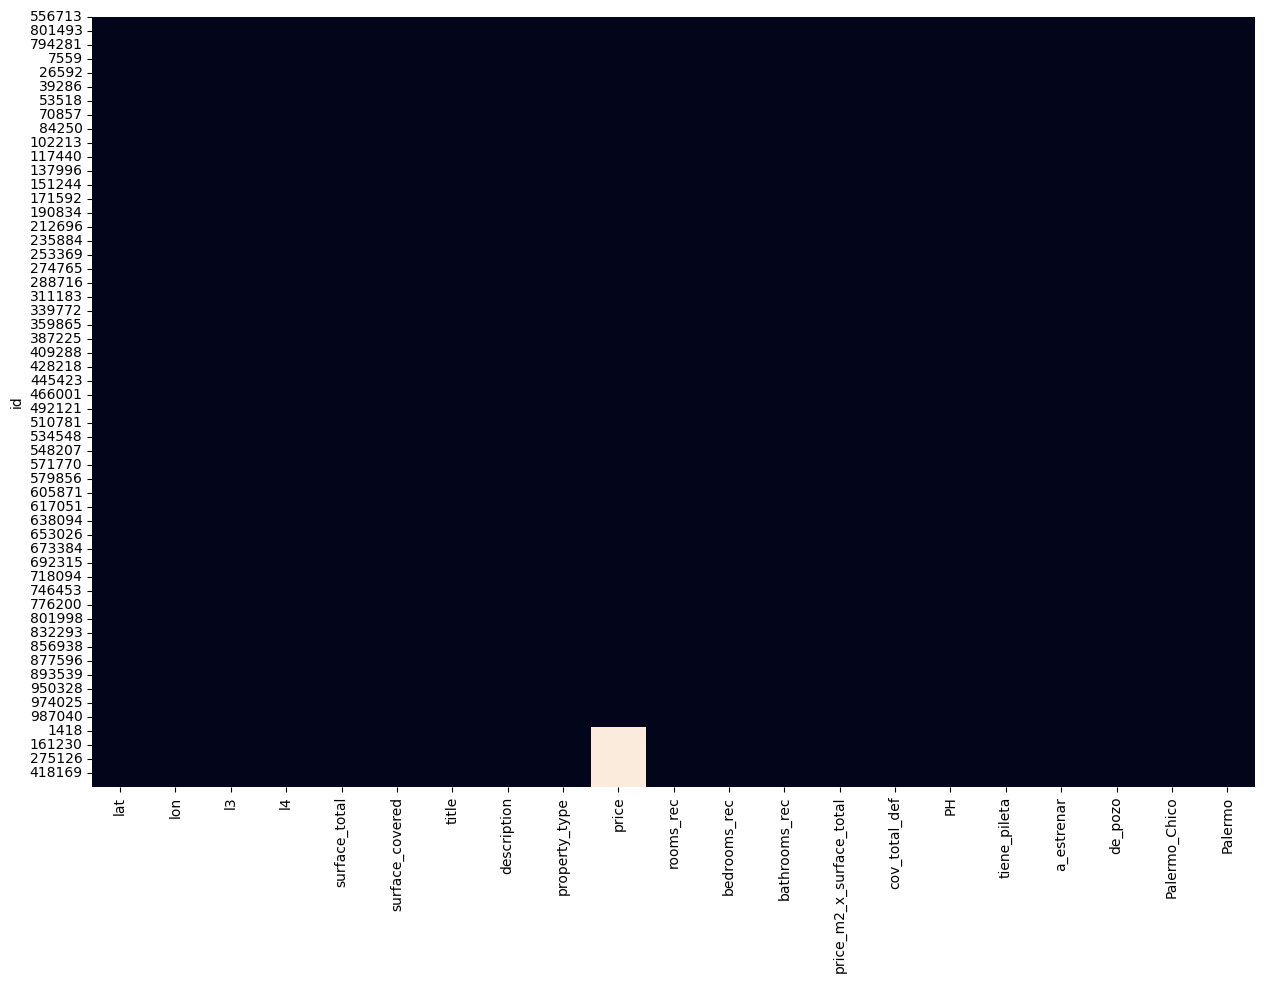

In [23]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Deptos.df.isnull(), cbar=False)

<Axes: ylabel='id'>

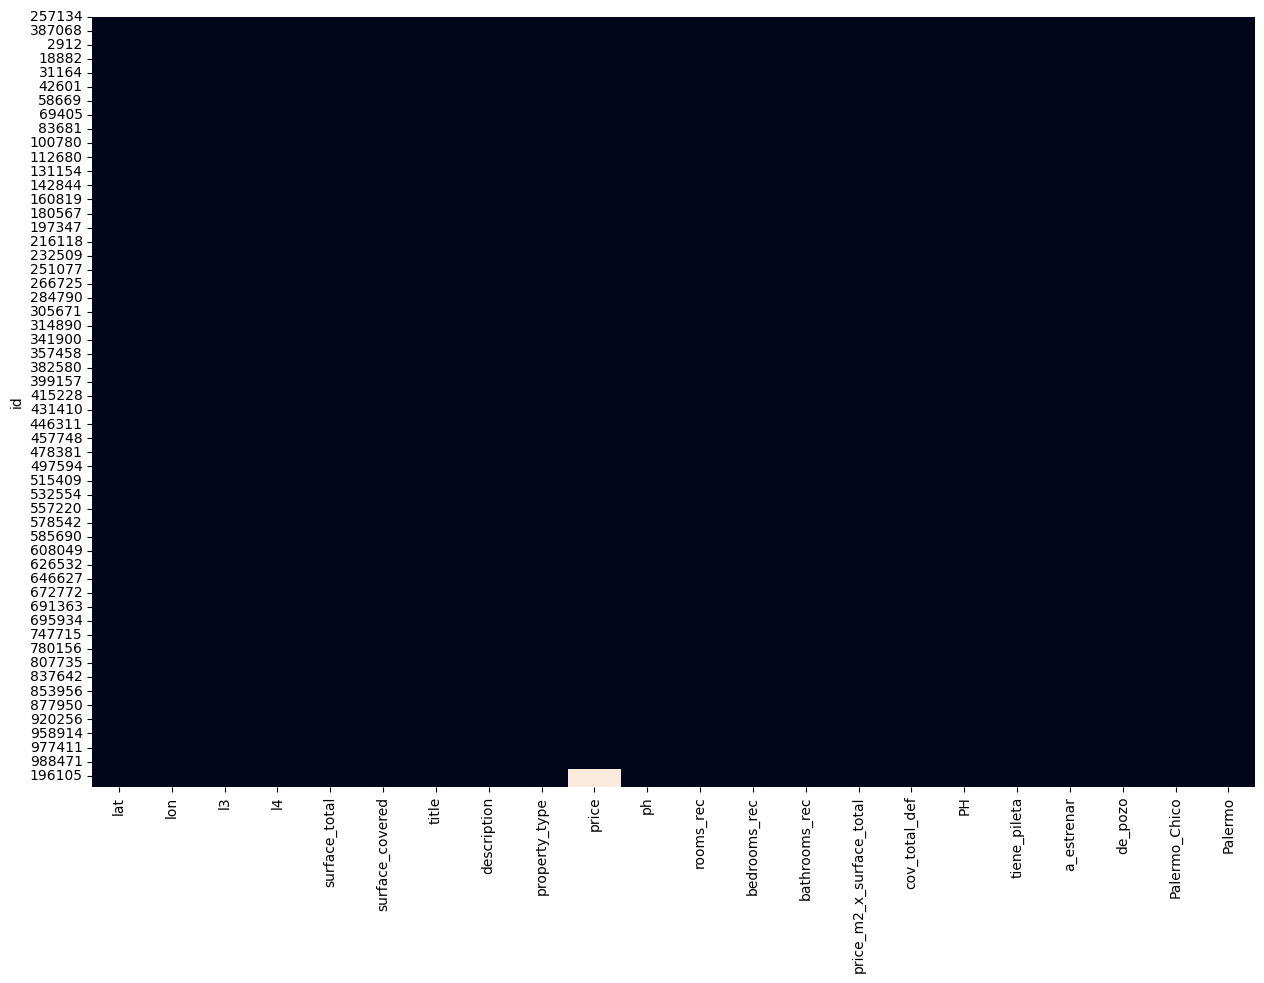

In [24]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Casas.df.isnull(), cbar=False)

<Axes: ylabel='id'>

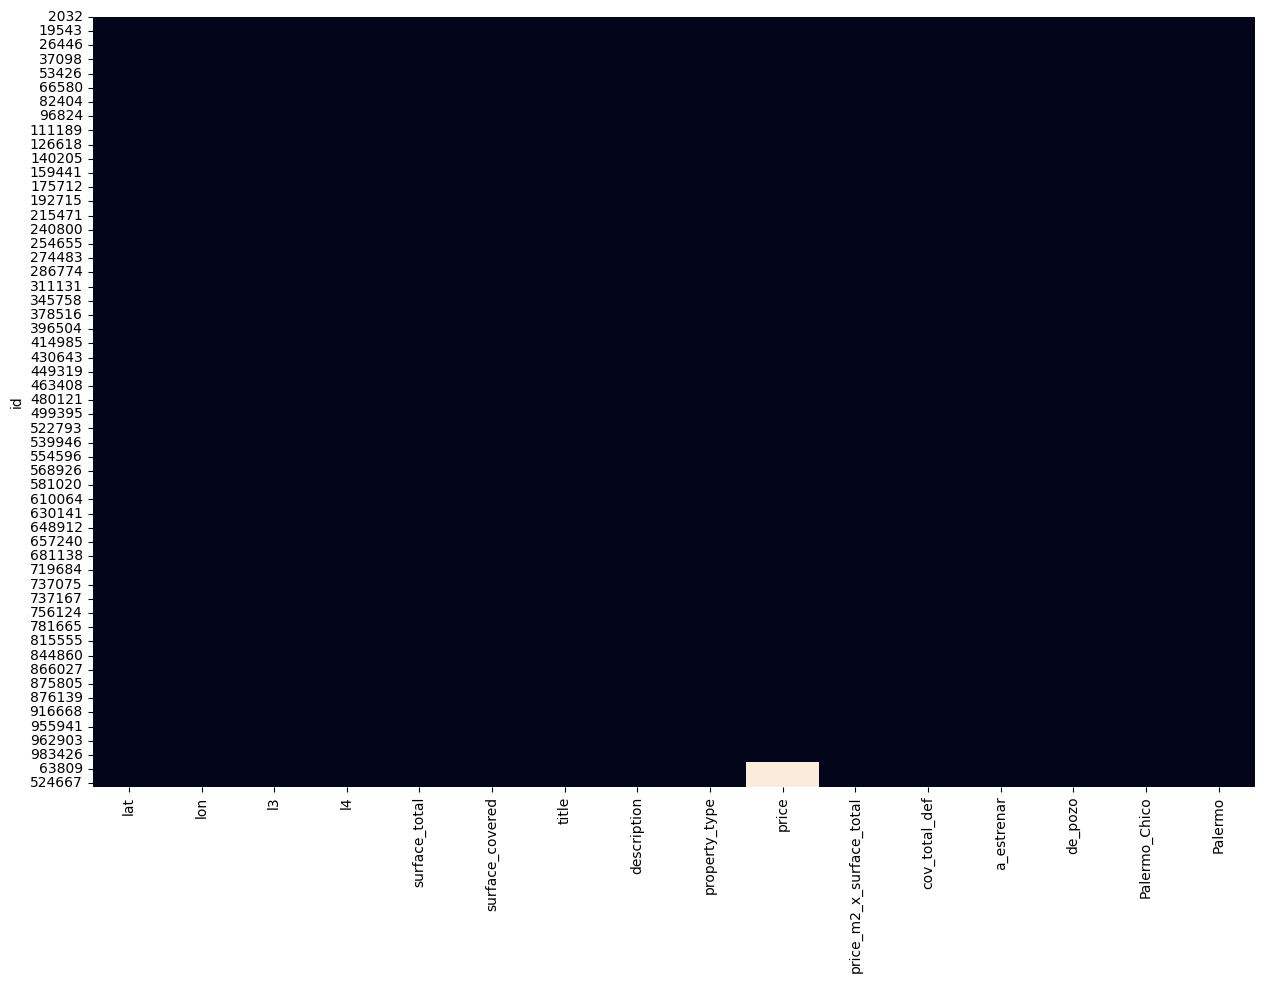

In [25]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Coch.df.isnull(), cbar=False)

## 3. Entrenamiento del modelos (AA)

### Tests de hiperparametros

In [27]:
Deptos.model_entrenamiento(modo="version_train_test_split_elegido")

shape df_ent: (78664, 21)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_elegido
n_estimators=500 -- max_depth=30 --> score_train=24502.33 - score_test=63894.82 - best_score_test=63894.82


In [28]:
Casas.model_entrenamiento(modo="version_train_test_split_elegido")

shape df_ent: (14029, 22)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'ph',
       'rooms_rec', 'bedrooms_rec', 'bathrooms_rec',
       'price_m2_x_surface_total', 'cov_total_def', 'PH', 'tiene_pileta',
       'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_elegido
n_estimators=500 -- max_depth=30 --> score_train=43876.01 - score_test=122104.90 - best_score_test=122104.90


In [29]:
Coch.model_entrenamiento(modo="version_train_test_split_elegido")

shape df_ent: (2678, 16)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price',
       'price_m2_x_surface_total', 'cov_total_def', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_elegido
n_estimators=500 -- max_depth=30 --> score_train=41401.51 - score_test=124382.57 - best_score_test=124382.57


### Version final con hiperparametros elegidos

In [30]:
print("DEPTOS")
print("")
Deptos.model_entrenamiento(modo="version_entrenamiento_final")
Deptos.model_prediccion()
print("CASAS")
print("")
Casas.model_entrenamiento(modo="version_entrenamiento_final")
Casas.model_prediccion()

print("COCHERAS")
print("")
Coch.model_entrenamiento(modo="version_entrenamiento_final")
Coch.model_prediccion()

DEPTOS

shape df_ent: (78664, 21)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_entrenamiento_final
Modelo finalizado listo para la prediccion
shape df_ap: (6596, 21)
df_ap columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
Predicciones realizadas
CASAS

shape df_ent: (14029, 22)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'ph',
       'rooms_rec', 'bedrooms_rec', 'bathrooms_rec',
       'price_m2_x_surface_total', 'cov_total_def', 'PH', 'tiene_pileta',
       'a_estren

In [31]:
df_ap_concat = pd.concat([Deptos.df_ap[["price"]] , Casas.df_ap[["price"]] , Coch.df_ap[["price"]]], axis=0)

In [32]:
df_ap_concat["price"].to_csv("solucion_v4_hp.csv")

### Evaluacion

In [33]:
# Deptos
X = Deptos.df_ent[Deptos.df_ent.columns.drop('price')]
importances_dpto=pd.DataFrame({"importance": Deptos.reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances_dpto

,importance
price_m2_x_surface_total,0.769934
surface_covered,0.056640
cov_total_def,0.038437
lat,0.035592
lon,0.033316
surface_total,0.025919
tiene_pileta,0.013158
bathrooms_rec,0.007571
Palermo_Chico,0.005477
rooms_rec,0.003852


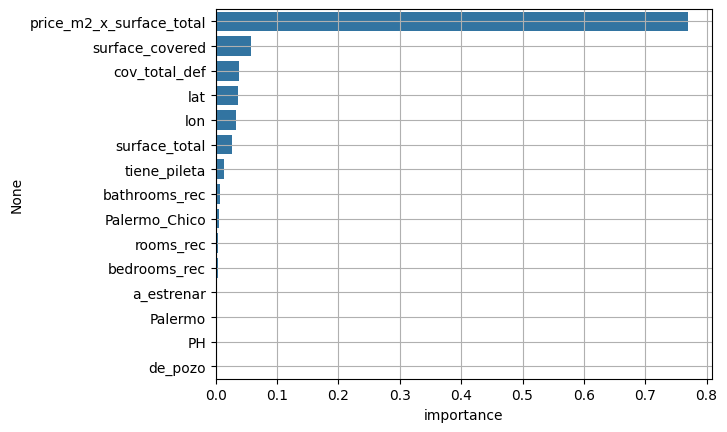

In [34]:
sns.barplot(data=importances_dpto,x="importance",y=importances_dpto.index)
plt.grid(True)
plt.show()

In [35]:
# Casas
X = Casas.df_ent[Casas.df_ent.columns.drop('price')]
importances_casa=pd.DataFrame({"importance": Casas.reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances_casa

,importance
price_m2_x_surface_total,0.640735
Palermo_Chico,0.115081
cov_total_def,0.051157
lon,0.044240
lat,0.041737
surface_covered,0.041558
surface_total,0.026700
bathrooms_rec,0.014375
rooms_rec,0.005639
bedrooms_rec,0.005522


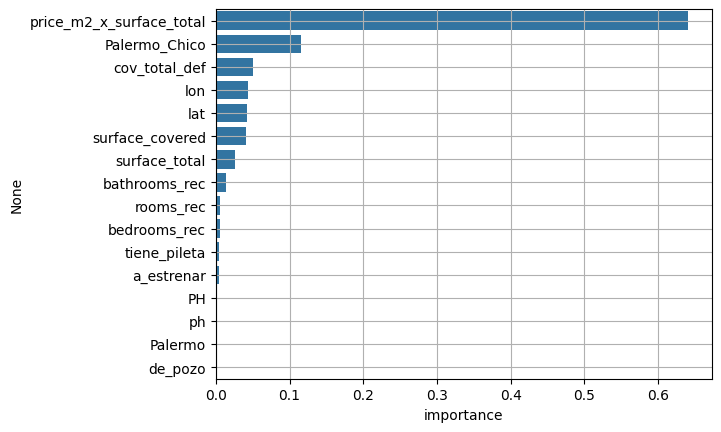

In [36]:
sns.barplot(data=importances_casa,x="importance",y=importances_casa.index)
plt.grid(True)
plt.show()

In [37]:
# Coch
X = Coch.df_ent[Coch.df_ent.columns.drop('price')]
importances_coch=pd.DataFrame({"importance": Coch.reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances_coch

,importance
lon,0.569955
lat,0.321034
a_estrenar,0.051513
price_m2_x_surface_total,0.038446
cov_total_def,0.007804
surface_covered,0.007050
Palermo,0.002268
surface_total,0.001389
Palermo_Chico,0.000502
de_pozo,0.000039


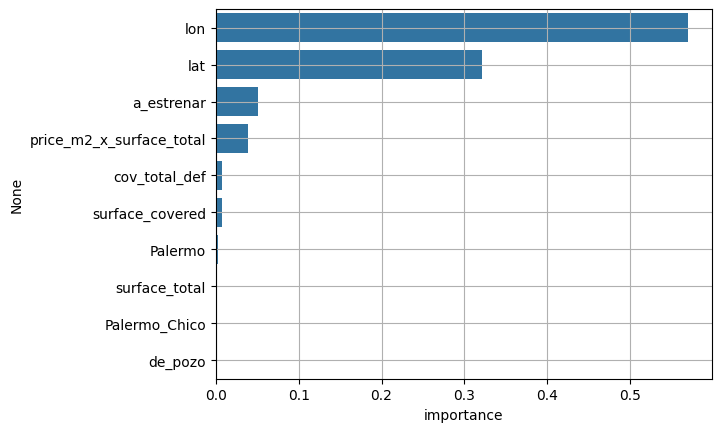

In [38]:
sns.barplot(data=importances_coch,x="importance",y=importances_coch.index)
plt.grid(True)
plt.show()